In [1]:
!pip uninstall scipy scikit-learn -y
!pip install scipy==1.13.0 scikit-learn==1.4.0 -q
!pip install monai livelossplot torchmetrics seaborn -q
!git clone https://github.com/monicaccmartins/MIQR-CC-Dataset.git

Found existing installation: scipy 1.13.0
Uninstalling scipy-1.13.0:
  Successfully uninstalled scipy-1.13.0
Found existing installation: scikit-learn 1.4.0
Uninstalling scikit-learn-1.4.0:
  Successfully uninstalled scikit-learn-1.4.0
fatal: destination path 'MIQR-CC-Dataset' already exists and is not an empty directory.


⚡️ Tip	Connect GitHub to Studios: https://lightning.ai/pg60017/home?settings=integrations



In [1]:
from livelossplot import PlotLosses 
from livelossplot.outputs import MatplotlibPlot
%matplotlib inline
import matplotlib.pyplot as plt
from monai.transforms import (Activations, AsDiscrete, LoadImage, EnsureChannelFirst, Resize,
                                RandZoom, RandAdjustContrast, RandGaussianNoise, RandRotate,
                                RandFlip, ToTensor, Compose, NormalizeIntensity, Lambda)
from monai.data import decollate_batch, DataLoader
from monai.metrics import ROCAUCMetric
from monai.losses import FocalLoss
from monai.utils import set_determinism
from monai.config import print_config
import numpy as np
import os
import random
from PIL import Image
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
import time
import torch
from torch.utils.data import Dataset, WeightedRandomSampler
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
import torch.nn as nn
from torchmetrics.classification import MulticlassF1Score

np.random.seed(0)
set_determinism(seed=0)
print_config()

MONAI version: 1.5.2
Numpy version: 1.26.4
Pytorch version: 2.8.0+cu128
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: d18565fb3e4fd8c556707f91ac280a2dc3f681c1
MONAI __file__: /home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: NOT INSTALLED or UNKNOWN VERSION.
scikit-image version: NOT INSTALLED or UNKNOWN VERSION.
scipy version: 1.13.0
Pillow version: 12.1.1
Tensorboard version: 2.20.0
gdown version: NOT INSTALLED or UNKNOWN VERSION.
TorchVision version: 0.23.0+cu128
tqdm version: 4.66.1
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 7.2.2
pandas version: 3.0.3
einops version: NOT INSTALLED or UNKNOWN VERSION.
transformers version: NOT INSTALLED or UNKNOWN VERSION.
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKN

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [3]:
base_dir = './MIQR-CC-Dataset/training/dataset'
phases = ['train', 'val', 'test']

data = {phase: {'images': [], 'labels': []} for phase in phases}
class_names = sorted([x for x in os.listdir(os.path.join(base_dir, 'train'))
                      if os.path.isdir(os.path.join(base_dir, 'train', x))])
num_class = len(class_names)
print("Classes:", class_names)

def load_images_labels(phase):
    for i, class_name in enumerate(class_names):
        class_dir = os.path.join(base_dir, phase, class_name)
        valid_exts = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')
        image_files = [
            os.path.join(class_dir, x)
            for x in os.listdir(class_dir)
            if x.lower().endswith(valid_exts)
        ]
        data[phase]['images'].extend(image_files)
        data[phase]['labels'].extend([i] * len(image_files))

for phase in phases:
    load_images_labels(phase)

for phase in phases:
    print(f"{phase.capitalize()} count =", len(data[phase]['images']))

Classes: ['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
Train count = 1067
Val count = 234
Test count = 267


In [4]:
def repeat_if_needed(img):
    if img.shape[0] == 1:
        return img.repeat(3, 1, 1)
    return img

train_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((512, 512)),
    RandRotate(range_x=15, prob=0.5),
    RandFlip(spatial_axis=0, prob=0.5),
    RandFlip(spatial_axis=1, prob=0.5),
    RandZoom(min_zoom=0.9, max_zoom=1.1, prob=0.5),
    RandAdjustContrast(prob=0.5),
    RandGaussianNoise(prob=0.3, mean=0.0, std=0.01),
    NormalizeIntensity(),
    Lambda(repeat_if_needed),
    ToTensor()
])

val_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((512, 512)),
    NormalizeIntensity(),
    Lambda(repeat_if_needed),
    ToTensor()
])

act = Activations(softmax=True)
to_onehot = AsDiscrete(to_onehot=num_class)

In [5]:
class MedNISTDataset(Dataset):
    def __init__(self, image_files, labels, transforms):
        self.image_files = image_files
        self.labels = labels
        self.transforms = transforms

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index):
        return self.transforms(self.image_files[index]), self.labels[index]

labels_train = data['train']['labels']
class_counts = np.bincount(labels_train)
class_weights = 1.0 / class_counts
sample_weights = [class_weights[l] for l in labels_train]
sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.float),
    num_samples=len(sample_weights),
    replacement=True
)

train_ds = MedNISTDataset(data['train']['images'], data['train']['labels'], train_transforms)
val_ds = MedNISTDataset(data['val']['images'], data['val']['labels'], val_transforms)
test_ds = MedNISTDataset(data['test']['images'], data['test']['labels'], val_transforms)

# batch_size=8 — mudança face à v8
train_loader = DataLoader(train_ds, batch_size=8, sampler=sampler, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=8, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=8, num_workers=0)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Train batches: 134
Val batches: 30


In [6]:
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'max_split_size_mb:128'
torch.cuda.empty_cache()

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"A usar: {device}")

model = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_class)
model = model.to(device)

print("Modelo pronto — backbone NÃO congelado")
print(f"Parâmetros treináveis: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

A usar: cuda:0
Modelo pronto — backbone NÃO congelado
Parâmetros treináveis: 2,228,996


In [9]:
def train_model(train_dl, val_dl, model, loss_function, optimizer, epochs, name):
    early_stopping_patience = 15
    epochs_without_improvement = 0
    liveloss = PlotLosses(outputs=[MatplotlibPlot(figpath=f"{name}.png")])
    best_metric = -1
    best_metric_epoch = -1
    metric_values = list()

    f1_metric = MulticlassF1Score(num_classes=num_class, average='macro').to(device)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=5
    )

    for epoch in range(epochs):
        logs = {}
        model.train()
        epoch_loss = 0
        running_loss = 0.0
        running_corrects = 0.0
        y_pred_train = torch.tensor([], dtype=torch.float32, device=device)
        y_train = torch.tensor([], dtype=torch.long, device=device)

        for inputs, labels in train_dl:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            loss = loss_function(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.detach() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels.data)
            y_pred_train = torch.cat([y_pred_train, outputs], dim=0)
            y_train = torch.cat([y_train, labels], dim=0)

        epoch_loss = running_loss / len(train_dl.dataset)
        epoch_acc = running_corrects.float() / len(train_dl.dataset)
        pred_train_labels = y_pred_train.argmax(dim=1)
        f1_train_value = f1_metric(pred_train_labels, y_train)

        logs['loss'] = epoch_loss.item()
        logs['accuracy'] = epoch_acc.item()
        logs['F1'] = f1_train_value.item()

        model.eval()
        running_loss = 0.0
        running_corrects = 0.0
        y_pred = torch.tensor([], dtype=torch.float32, device=device)
        y = torch.tensor([], dtype=torch.long, device=device)

        with torch.no_grad():
            for val_images, val_labels in val_dl:
                val_images = val_images.to(device)
                val_labels = val_labels.to(device)
                outputs = model(val_images)
                loss = loss_function(outputs, val_labels)
                running_loss += loss.detach() * val_images.size(0)
                _, preds = torch.max(outputs, 1)
                running_corrects += torch.sum(preds == val_labels.data)
                y_pred = torch.cat([y_pred, outputs], dim=0)
                y = torch.cat([y, val_labels], dim=0)

            epoch_loss = running_loss / len(val_dl.dataset)
            epoch_acc = running_corrects.float() / len(val_dl.dataset)
            logs['val_loss'] = epoch_loss.item()
            logs['val_accuracy'] = epoch_acc.item()

            pred_labels = y_pred.argmax(dim=1)
            f1_score_value = f1_metric(pred_labels, y)
            logs['val_F1'] = f1_score_value.item()

            y_onehot = [to_onehot(i) for i in decollate_batch(y, detach=False)]
            y_pred_act = [act(i) for i in decollate_batch(y_pred)]
            auc_metric(y_pred_act, y_onehot)
            result = auc_metric.aggregate()
            auc_metric.reset()
            del y_pred_act, y_onehot
            metric_values.append(result)

            if f1_score_value > best_metric:
                best_metric = f1_score_value
                best_metric_epoch = epoch + 1
                best_train_f1 = f1_train_value.item()
                torch.save(model.state_dict(), name)
                print('saved new best metric model')
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            if epochs_without_improvement >= early_stopping_patience:
                print(
                    f"Early stopping at epoch {epoch + 1} \n"
                    f" Best Val F1: {best_metric:.4f} \n"
                    f" Best Train F1: {best_train_f1:.4f} \n"
                    f" current Val F1: {f1_score_value:.4f} \n"
                    f" current Train F1: {f1_train_value:.4f} \n"
                    f" Best epoch: {best_metric_epoch} \n"
                )
                break
            print(
                f"current epoch: {epoch + 1} current AUC: {result:.4f}"
                f" current F1 (train): {f1_train_value:.4f}"
                f" current F1 (val): {f1_score_value:.4f}"
                f" best F1: {best_metric:.4f}"
                f" at epoch: {best_metric_epoch}"
            )

        logs['val_AUC'] = result
        liveloss.update(logs)
        liveloss.send()
        scheduler.step(f1_score_value)

    print(f"train completed, best_metric: {best_metric:.4f} at epoch: {best_metric_epoch}")

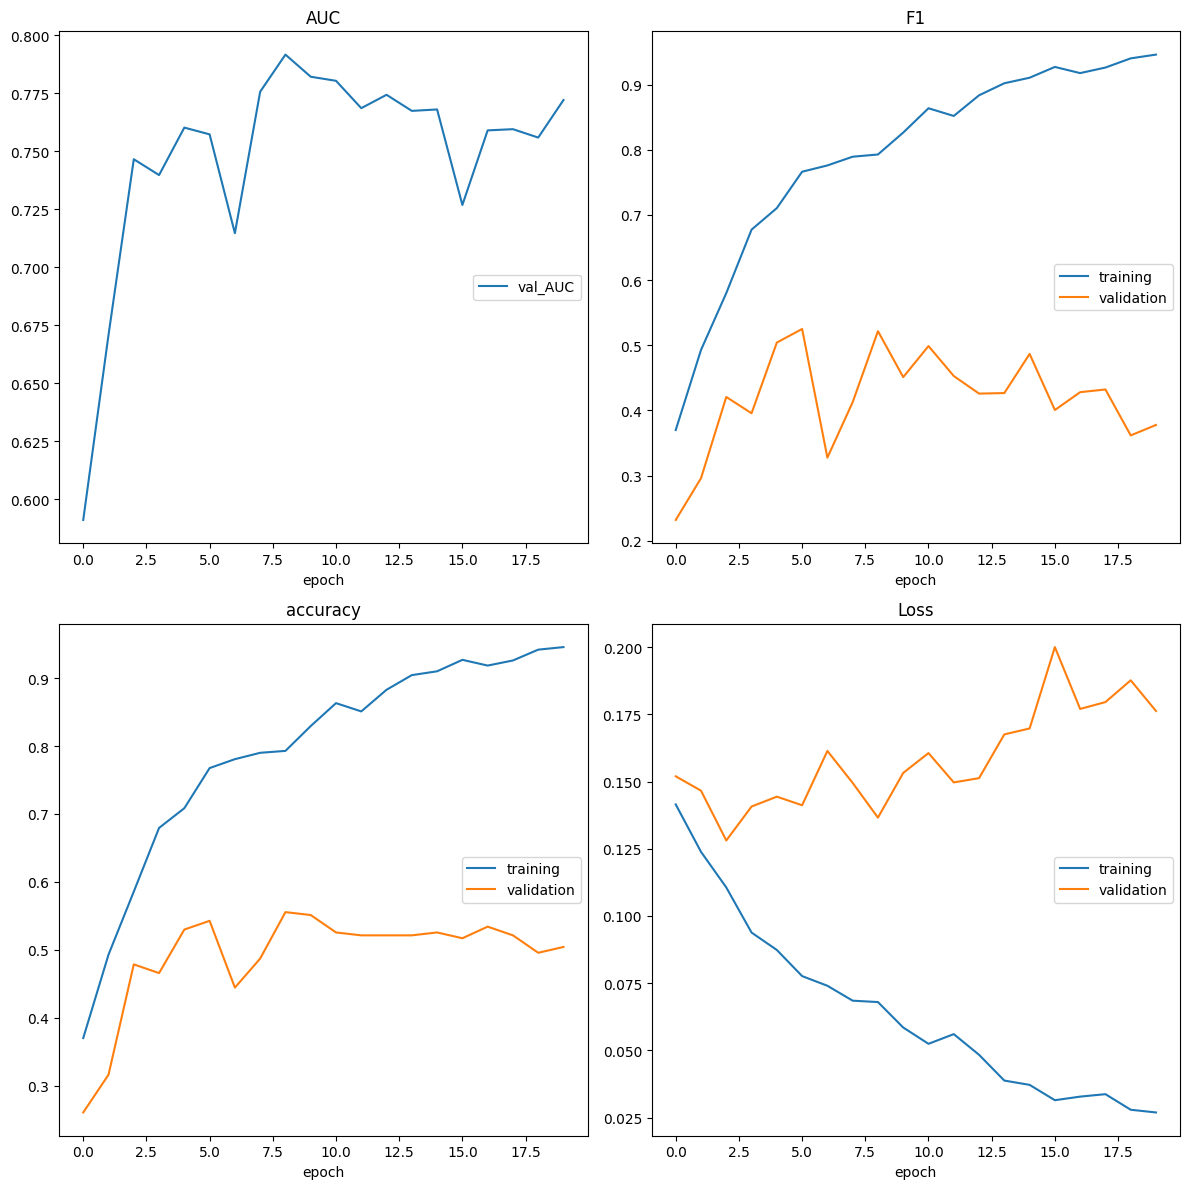

Early stopping at epoch 21 
 Best Val F1: 0.5250 
 Best Train F1: 0.7662 
 current Val F1: 0.4012 
 current Train F1: 0.9443 
 Best epoch: 6 

train completed, best_metric: 0.5250 at epoch: 6
Treino concluído em 1334.0 segundos


In [10]:
model_name = 'mobilenet_v2_teresa_v9.pth'
auc_metric = ROCAUCMetric()

EPOCHS = 80
LR = 1e-4

loss_function = FocalLoss(to_onehot_y=True)
optimizer = torch.optim.Adam(model.parameters(), LR)

starttime = time.perf_counter()
train_model(train_loader, val_loader, model, loss_function, optimizer, EPOCHS, model_name)
endtime = time.perf_counter()
print(f"Treino concluído em {endtime - starttime:.1f} segundos")

F1 Score no teste: 0.5795
               precision    recall  f1-score   support

Biliary_Leaks     0.5833    0.4118    0.4828        17
    Lithiasis     0.6184    0.7642    0.6836       123
       Normal     0.5263    0.4651    0.4938        43
    Stricture     0.7538    0.5833    0.6577        84

     accuracy                         0.6367       267
    macro avg     0.6205    0.5561    0.5795       267
 weighted avg     0.6440    0.6367    0.6321       267



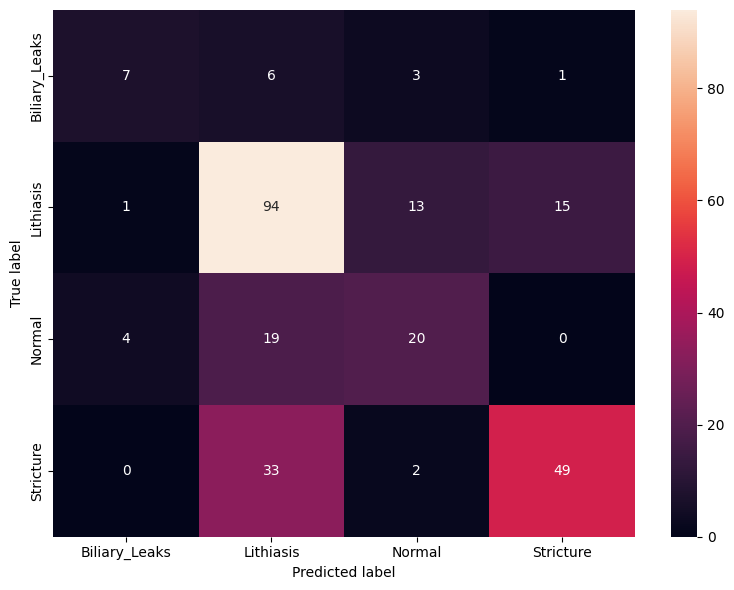

In [13]:
def evaluate_model(test_dl, model):
    model.load_state_dict(torch.load(model_name, map_location=device))
    model.eval()
    predictions = []
    actual_values = []

    with torch.no_grad():
        for inputs, labels in test_dl:
            inputs = inputs.to(device)
            yprev = model(inputs)
            yprev = yprev.detach().cpu().numpy()
            actual = labels.cpu().numpy()
            yprev = np.argmax(yprev, axis=1)
            actual = actual.reshape((len(actual), 1))
            yprev = yprev.reshape((len(yprev), 1))
            predictions.append(yprev)
            actual_values.append(actual)

    predictions, actual_values = np.vstack(predictions), np.vstack(actual_values)
    f1 = f1_score(actual_values, predictions, average='macro')
    print(f"F1 Score no teste: {f1:.4f}")
    print(classification_report(actual_values, predictions,
                                target_names=class_names, digits=4, zero_division=0))

    cm = confusion_matrix(actual_values, predictions)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, xticklabels=class_names,
                yticklabels=class_names, fmt='g')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

    return actual_values, predictions

actual_values, predictions = evaluate_model(test_loader, model)

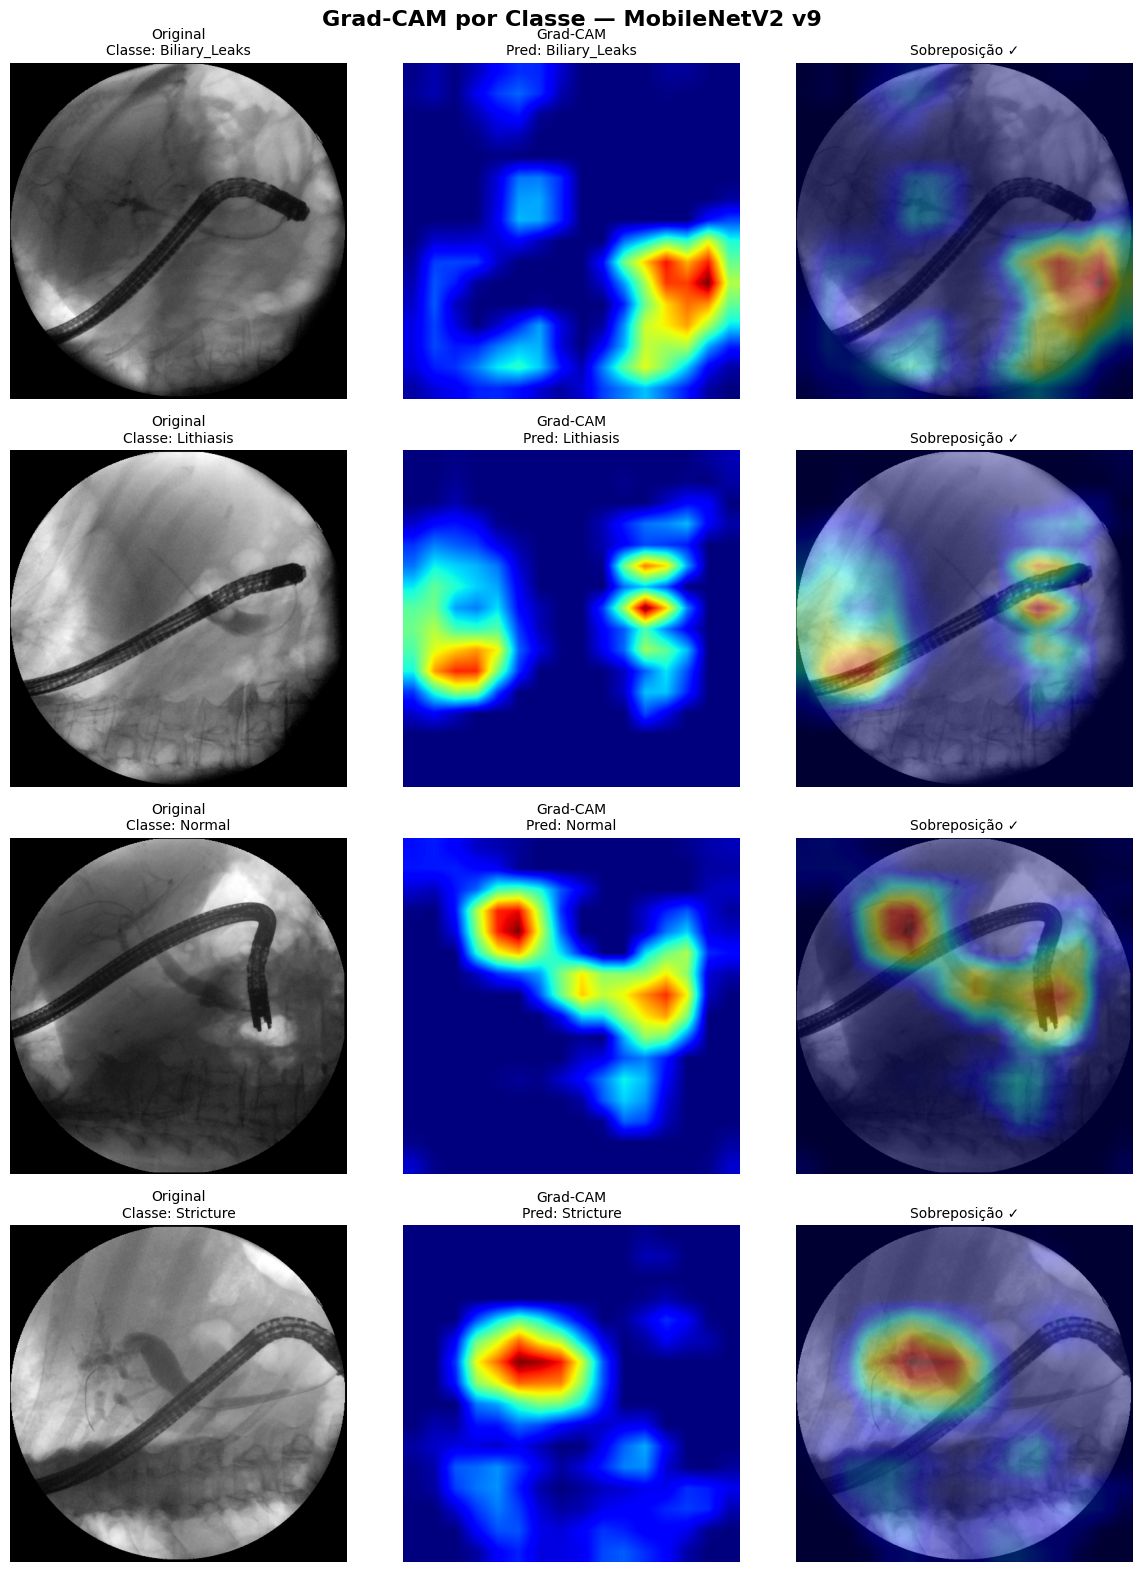

Grad-CAM guardado!


In [12]:
import torch.nn.functional as F

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()
        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()
        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        self.model.zero_grad()
        one_hot = torch.zeros_like(output)
        one_hot[0][class_idx] = 1
        output.backward(gradient=one_hot)
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=input_tensor.shape[2:], mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx

def show_gradcam_per_class(model, dataset, class_names, device):
    target_layer = model.features[-1][0]
    gradcam = GradCAM(model, target_layer)
    model.load_state_dict(torch.load(model_name, map_location=device))
    model.eval()

    num_classes = len(class_names)
    fig, axes = plt.subplots(num_classes, 3, figsize=(12, num_classes * 4))
    fig.suptitle('Grad-CAM por Classe — MobileNetV2 v9', fontsize=16, fontweight='bold')

    class_indices = {}
    for i, (_, label) in enumerate(dataset):
        if label not in class_indices:
            class_indices[label] = i
        if len(class_indices) == num_classes:
            break

    for idx, (class_id, sample_idx) in enumerate(sorted(class_indices.items())):
        img_tensor, true_label = dataset[sample_idx]
        input_tensor = img_tensor.unsqueeze(0).to(device)
        cam, pred_class = gradcam.generate(input_tensor, class_idx=class_id)
        img_np = img_tensor[0].cpu().numpy()
        img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)
        heatmap = plt.cm.jet(cam)[:, :, :3]
        overlay = 0.6 * np.stack([img_np]*3, axis=-1) + 0.4 * heatmap
        overlay = np.clip(overlay, 0, 1)

        axes[idx, 0].imshow(img_np, cmap='gray')
        axes[idx, 0].set_title(f'Original\nClasse: {class_names[true_label]}', fontsize=10)
        axes[idx, 0].axis('off')
        axes[idx, 1].imshow(cam, cmap='jet')
        axes[idx, 1].set_title(f'Grad-CAM\nPred: {class_names[pred_class]}', fontsize=10)
        axes[idx, 1].axis('off')
        axes[idx, 2].imshow(overlay)
        correct = "✓" if pred_class == true_label else "✗"
        axes[idx, 2].set_title(f'Sobreposição {correct}', fontsize=10)
        axes[idx, 2].axis('off')

    plt.tight_layout()
    plt.savefig('gradcam_mobilenet_v9.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Grad-CAM guardado!")

show_gradcam_per_class(model, test_ds, class_names, device)